In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Parametry gry

In [495]:
MOVES = ["papier", "kamien", "nozyce"]

Initial_State_Distribution = {
    "papier": 1/3,
    "kamien": 1/3,
    "nozyce": 1/3
}

Transition_Matrix = {
    "papier": {"papier": 0.1, "kamien": 0.7, "nozyce": 0.2},
    "kamien": {"papier": 0.5, "kamien": 0.0, "nozyce": 0.5},
    "nozyce": {"papier": 0.25, "kamien": 0.25, "nozyce": 0.5}
}

##

## Macierze predykcji i liczników

In [496]:
Prediction_Matrix = {
    move: {next_move: 1/3 for next_move in MOVES}
    for move in MOVES
}

Count_Matrix = {
    move: {next_move: 1 for next_move in MOVES}
    for move in MOVES
}

## Funkcja losowania z rozkładu

In [497]:
def sample_from_dict(prob_dict):
    """Losuje klucz ze słownika zgodnie z podanymi prawdopodobieństwami."""
    outcomes = list(prob_dict.keys())
    probabilities = list(prob_dict.values())
    return np.random.choice(outcomes, p=probabilities)

## Funkcja kontr-ruchu

In [498]:
def counter_move(move):
  if move == "papier":
      return "nozyce"
  elif move == "kamien":
      return "papier"
  elif move == "nozyce":
      return "kamien"

## Funkcja wyniku rundy

In [499]:
def win_draw_defeat(players_choice, opponents_choice):
    """1 -> win, 0 -> draw, -1 -> defeat"""
    if players_choice == opponents_choice:
        return 0

    winning_pairs = {
        ("papier", "kamien"),
        ("kamien", "nozyce"),
        ("nozyce", "papier")
    }

    if (players_choice, opponents_choice) in winning_pairs:
        return 1
    return -1

## Funkcja aktualizacji macierzy predykcji

In [500]:
def update_prediction_matrix(count_matrix, prediction_matrix, current_move):
    total = sum(count_matrix[current_move].values())
    for next_move in prediction_matrix[current_move]:
        prediction_matrix[current_move][next_move] = (
            count_matrix[current_move][next_move] / total
        )

## Symulacja

In [501]:
N_ROUNDS = 1000

fights_results = []
fights_results_cumulative_sum = [0]

item = sample_from_dict(Initial_State_Distribution)

for _ in range(N_ROUNDS):
    # Gracz 1 generuje następny ruch
    next_item = sample_from_dict(Transition_Matrix[item])

    # Gracz 2 przewiduje następny ruch gracza 1
    predicted_item = max(Prediction_Matrix[item], key=Prediction_Matrix[item].get)

    # Gracz 2 wybiera kontr-ruch
    counter_item = counter_move(predicted_item)

    # Wynik rundy
    fight_result = win_draw_defeat(counter_item, next_item)
    fights_results.append(fight_result)
    fights_results_cumulative_sum.append(fights_results_cumulative_sum[-1] + fight_result)

    # Aktualizacja zliczeń
    Count_Matrix[item][next_item] += 1

    # Aktualizacja oszacowanych prawdopodobieństw
    update_prediction_matrix(Count_Matrix, Prediction_Matrix, item)

    # Przejście do kolejnego stanu
    item = next_item

## Wynik końcowy

In [502]:
print("Wyuczona macierz przejść:")
for move in MOVES:
    print(move, Prediction_Matrix[move])

print("Prawdziwa macierz przejść:")
for move in MOVES:
    print(move, Transition_Matrix[move])

Wyuczona macierz przejść:
papier {'papier': 0.10884353741496598, 'kamien': 0.6870748299319728, 'nozyce': 0.20408163265306123}
kamien {'papier': 0.5160256410256411, 'kamien': 0.003205128205128205, 'nozyce': 0.4807692307692308}
nozyce {'papier': 0.2506203473945409, 'kamien': 0.2704714640198511, 'nozyce': 0.47890818858560796}
Prawdziwa macierz przejść:
papier {'papier': 0.1, 'kamien': 0.7, 'nozyce': 0.2}
kamien {'papier': 0.5, 'kamien': 0.0, 'nozyce': 0.5}
nozyce {'papier': 0.25, 'kamien': 0.25, 'nozyce': 0.5}


## Wykres

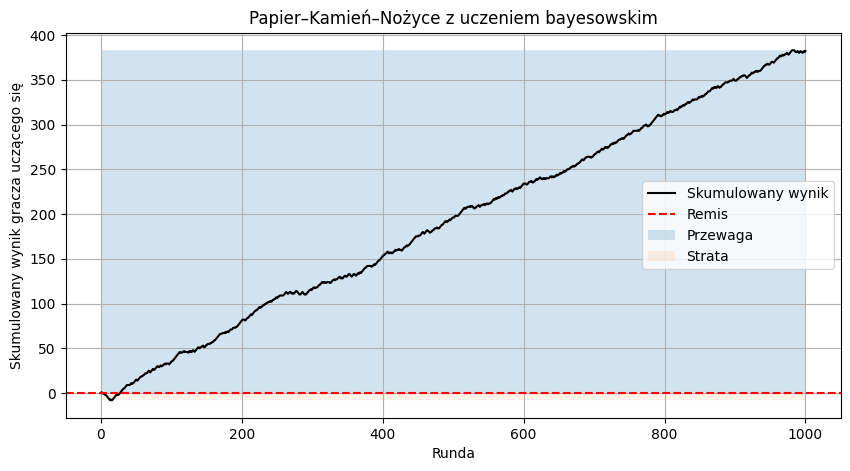

In [503]:
plt.figure(figsize=(10, 5))
plt.plot(fights_results_cumulative_sum, color="black", label="Skumulowany wynik")
plt.title("Papier–Kamień–Nożyce z uczeniem bayesowskim")
plt.axhline(0, color="red", linestyle="--", label="Remis")
plt.xlabel("Runda")
plt.ylabel("Skumulowany wynik gracza uczącego się")

x = np.arange(len(fights_results_cumulative_sum))
plt.fill_between(x, 0, max(fights_results_cumulative_sum), alpha=0.2, label="Przewaga")
plt.fill_between(x, 0, min(fights_results_cumulative_sum), alpha=0.1, label="Strata")

plt.legend()
plt.grid(True)
plt.show()


## Statystyki końcowe

In [504]:
wins = sum(1 for x in fights_results if x == 1)
draws = sum(1 for x in fights_results if x == 0)
losses = sum(1 for x in fights_results if x == -1)

print("Liczba wygranych:", wins)
print("Liczba remisów:", draws)
print("Liczba porażek:", losses)
print("Wynik końcowy:", fights_results_cumulative_sum[-1])

Liczba wygranych: 547
Liczba remisów: 288
Liczba porażek: 165
Wynik końcowy: 382
